# Final Model Evaluation and Selection
---
## Objectives:
- Load top 3 models from MLflow
- Evaluate on held-out test set
- Calculate final business metrics
- Perform error analysis
- Make final model selection recommendation
- Generate deployment-ready model artifacts

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os  # <-- ADDED
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, auc, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
)
import joblib
from datetime import datetime

import json

mlflow.set_tracking_uri("mlruns")
print("Libraries imported successfully!")
print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")

Libraries imported successfully!
MLflow tracking URI: mlruns


In [2]:
print("Loading test data")
X_test = pd.read_csv('../data/interim/scaled/X_test.csv')
Y_test = pd.read_csv('../data/interim/label/Y_test.csv')

X_test.columns = X_test.columns.str.strip()
Y_test.columns = Y_test.columns.str.strip()

print(f"Test set shape: {X_test.shape}")
print(f"Test class distribution:\n{Y_test['is_fraud'].value_counts(normalize=True)}")

Loading test data
Test set shape: (1501, 16)
Test class distribution:
is_fraud
0    0.984677
1    0.015323
Name: proportion, dtype: float64


In [3]:
with open('../outputs/model_selection/text/final_top_3_models.txt', 'r') as f:
    top_3_model_names = [line.strip() for line in f.readlines()]

print("Top 3 models to evaluate:")
for i, model_name in enumerate(top_3_model_names, 1):
    print(f"  {i}. {model_name}")

Top 3 models to evaluate:
  1. LightGBM_v1
  2. LightGBM_Tuned
  3. XGBoost_Tuned


In [4]:
def load_model_from_mlflow(model_name):
    experiment = mlflow.get_experiment_by_name("credit_card_fraud_detection")
    
    # Tuned models have run names like "LightGBM_tuning_...", not "LightGBM_Tuned_..."
    search_name = model_name.replace("_Tuned", "_tuning")
    
    runs = mlflow.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"tags.mlflow.runName LIKE '{search_name}%'",
        order_by=["start_time DESC"]
    )
    
    if len(runs) == 0:
        raise ValueError(f"No runs found for model: {model_name}")
    
    latest_run = runs.iloc[0]
    run_id = latest_run['run_id']
    
    artifact_path = "tuned_model" if "_Tuned" in model_name else "model"
    model_uri = f"runs:/{run_id}/{artifact_path}"
    model = mlflow.sklearn.load_model(model_uri)
    
    print(f"Loaded model '{model_name}' from run: {run_id}")
    return model, run_id


print("Loading top 3 models from MLflow\n")
final_models = {}

for model_name in top_3_model_names:
    
    model, run_id = load_model_from_mlflow(model_name)
    final_models[model_name] = {
        'model': model,
        'run_id': run_id
    }

print(f"\nAll {len(final_models)} models loaded successfully!")

Loading top 3 models from MLflow



Loaded model 'LightGBM_v1' from run: 91740bf8a7be4e99baa37dfc79ec9fbe


Loaded model 'LightGBM_Tuned' from run: 8650f0033875499684c7b3ce2412270a


Loaded model 'XGBoost_Tuned' from run: 2964b439e4f248a484f56c5cc882eeaa

All 3 models loaded successfully!


In [5]:
def calculate_business_metrics(y_true, y_pred, y_proba=None, cost_fn=150, cost_fp=10, transaction_value=200):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    total_fraud_amount = fn * transaction_value
    false_alarm_cost = fp * cost_fp
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    detected_fraud = tp * transaction_value
    potential_savings = detected_fraud - false_alarm_cost
    
    business_metrics = {
        'true_positives': int(tp),
        'false_positives': int(fp),
        'true_negatives': int(tn),
        'false_negatives': int(fn),
        'fraud_detection_rate': round(tp / (tp + fn) * 100, 2),
        'false_alarm_rate': round(fp / (fp + tn) * 100, 2),
        'total_fraud_missed_amount': int(total_fraud_amount),
        'false_alarm_investigation_cost': int(false_alarm_cost),
        'total_business_cost': int(total_cost),
        'potential_savings': int(potential_savings),
        'roi_percentage': round((potential_savings / total_cost) * 100, 2) if total_cost > 0 else 0
    }
    
    return business_metrics

In [6]:
print("Evaluating models on test set\n")

final_evaluation_results = []

for model_name, model_info in final_models.items():
    print(f"Evaluating: {model_name}")
    
    model = model_info['model']
    
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else None
    
    accuracy = accuracy_score(Y_test['is_fraud'], y_test_pred)
    precision = precision_score(Y_test['is_fraud'], y_test_pred)
    recall = recall_score(Y_test['is_fraud'], y_test_pred)
    f1 = f1_score(Y_test['is_fraud'], y_test_pred)
    roc_auc = roc_auc_score(Y_test['is_fraud'], y_test_proba) if y_test_proba is not None else 0
    
    business_metrics = calculate_business_metrics(Y_test['is_fraud'], y_test_pred, y_test_proba)
    
    result = {
        'model_name': model_name,
        'run_id': model_info['run_id'],
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'roc_auc': roc_auc,
        'fraud_detection_rate': business_metrics['fraud_detection_rate'],
        'false_alarm_rate': business_metrics['false_alarm_rate'],
        'total_business_cost': business_metrics['total_business_cost'],
        'potential_savings': business_metrics['potential_savings'],
        'roi_percentage': business_metrics['roi_percentage'],
        'confusion_matrix': confusion_matrix(Y_test['is_fraud'], y_test_pred),
        'y_pred': y_test_pred,
        'y_proba': y_test_proba
    }
    final_evaluation_results.append(result)
    
    print(f"Evaluation complete.")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Fraud Detection Rate: {business_metrics['fraud_detection_rate']:.2f}%")
    print(f"False Alarm Rate: {business_metrics['false_alarm_rate']:.2f}%")
    print(f"Total Business Cost: ${business_metrics['total_business_cost']:,}")
    print(f"Potential Savings: ${business_metrics['potential_savings']:,}")
    print(f"ROI: {business_metrics['roi_percentage']:.2f}%")

print("All models evaluated on test set!")

Evaluating models on test set

Evaluating: LightGBM_v1
Evaluation complete.
Accuracy: 0.9887
Precision: 0.5789
Recall: 0.9565
F1-Score: 0.7213
ROC-AUC: 0.9970
Fraud Detection Rate: 95.65%
False Alarm Rate: 1.08%
Total Business Cost: $310
Potential Savings: $4,240
ROI: 1367.74%
Evaluating: LightGBM_Tuned
Evaluation complete.
Accuracy: 0.9927
Precision: 0.7308
Recall: 0.8261
F1-Score: 0.7755
ROC-AUC: 0.9971
Fraud Detection Rate: 82.61%
False Alarm Rate: 0.47%
Total Business Cost: $670
Potential Savings: $3,730
ROI: 556.72%
Evaluating: XGBoost_Tuned
Evaluation complete.
Accuracy: 0.9887
Precision: 0.5938
Recall: 0.8261
F1-Score: 0.6909
ROC-AUC: 0.9964
Fraud Detection Rate: 82.61%
False Alarm Rate: 0.88%
Total Business Cost: $730
Potential Savings: $3,670
ROI: 502.74%
All models evaluated on test set!


In [7]:
final_results_df = pd.DataFrame(final_evaluation_results)

display_columns = [
    'model_name', 'accuracy', 'precision', 'recall', 'f1_score', 
    'roc_auc', 'fraud_detection_rate', 'false_alarm_rate',
    'total_business_cost', 'potential_savings', 'roi_percentage'
]

final_table = final_results_df[display_columns].copy()
final_table = final_table.sort_values('f1_score', ascending=False)

print("FINAL MODEL EVALUATION RESULTS (TEST SET)")
print(final_table.to_string(index=False))

final_table.to_csv('../outputs/model_selection/csv/final_model_evaluation_results.csv', index=False)
print("\nFinal results saved as 'final_model_evaluation_results.csv'")

FINAL MODEL EVALUATION RESULTS (TEST SET)
    model_name  accuracy  precision   recall  f1_score  roc_auc  fraud_detection_rate  false_alarm_rate  total_business_cost  potential_savings  roi_percentage
LightGBM_Tuned  0.992672   0.730769 0.826087  0.775510 0.997117                 82.61              0.47                  670               3730          556.72
   LightGBM_v1  0.988674   0.578947 0.956522  0.721311 0.997029                 95.65              1.08                  310               4240         1367.74
 XGBoost_Tuned  0.988674   0.593750 0.826087  0.690909 0.996352                 82.61              0.88                  730               3670          502.74

Final results saved as 'final_model_evaluation_results.csv'


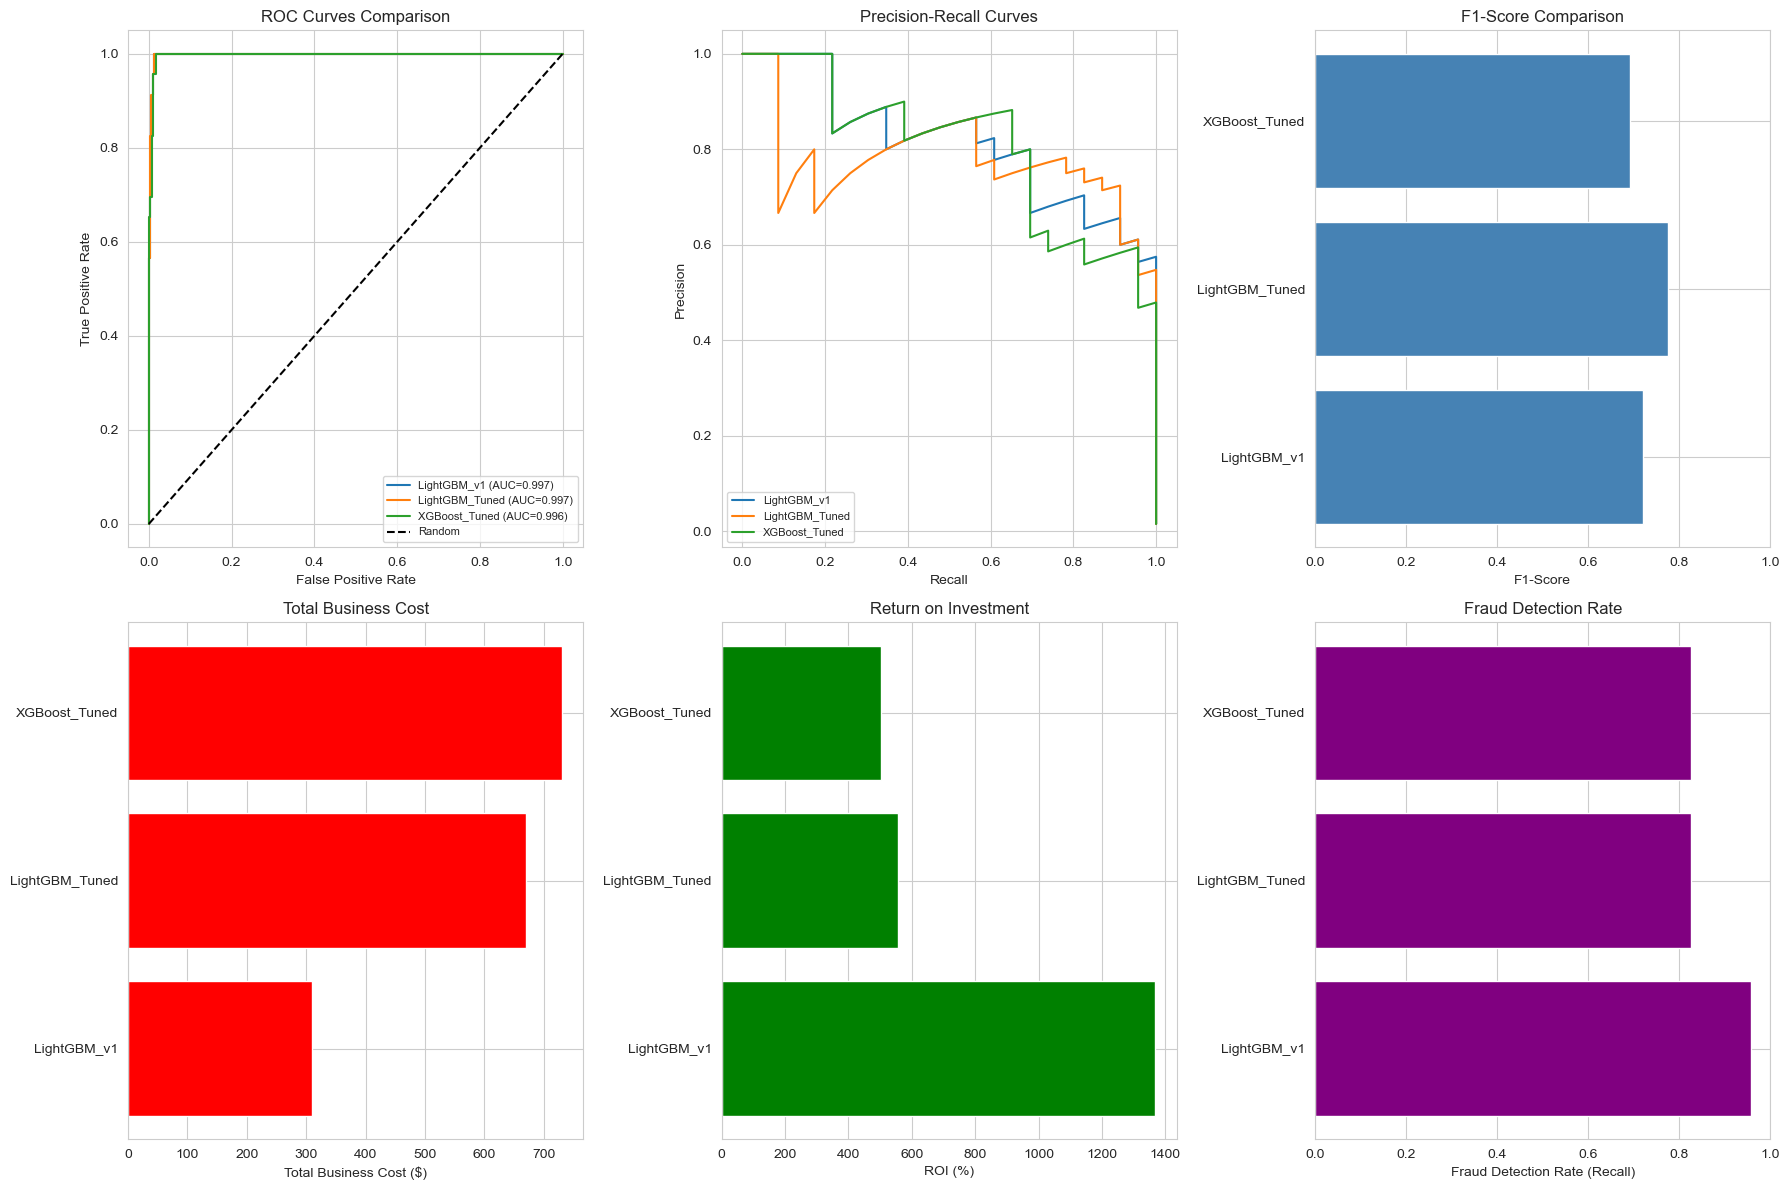

Final evaluation charts saved as 'final_model_evaluation_charts.png'


In [8]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for result in final_evaluation_results:
    if result['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(Y_test['is_fraud'], result['y_proba'])
        axes[0, 0].plot(fpr, tpr, label=f"{result['model_name']} (AUC={result['roc_auc']:.3f})")

axes[0, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].set_title('ROC Curves Comparison')
axes[0, 0].legend(loc='lower right', fontsize=8)

for result in final_evaluation_results:
    if result['y_proba'] is not None:
        precision, recall, _ = precision_recall_curve(Y_test['is_fraud'], result['y_proba'])
        axes[0, 1].plot(recall, precision, label=f"{result['model_name']}")

axes[0, 1].set_xlabel('Recall')
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_title('Precision-Recall Curves')
axes[0, 1].legend(loc='lower left', fontsize=8)

axes[0, 2].barh(final_results_df['model_name'], final_results_df['f1_score'], color='steelblue')
axes[0, 2].set_xlabel('F1-Score')
axes[0, 2].set_title('F1-Score Comparison')
axes[0, 2].set_xlim([0, 1])

axes[1, 0].barh(final_results_df['model_name'], final_results_df['total_business_cost'], color='red')
axes[1, 0].set_xlabel('Total Business Cost ($)')
axes[1, 0].set_title('Total Business Cost')

axes[1, 1].barh(final_results_df['model_name'], final_results_df['roi_percentage'], color='green')
axes[1, 1].set_xlabel('ROI (%)')
axes[1, 1].set_title('Return on Investment')

axes[1, 2].barh(final_results_df['model_name'], final_results_df['recall'], color='purple')
axes[1, 2].set_xlabel('Fraud Detection Rate (Recall)')
axes[1, 2].set_title('Fraud Detection Rate')
axes[1, 2].set_xlim([0, 1])

plt.tight_layout()
plt.savefig('../outputs/model_selection/images/final_model_evaluation_charts.png', dpi=300, bbox_inches='tight')
plt.show()

print("Final evaluation charts saved as 'final_model_evaluation_charts.png'")

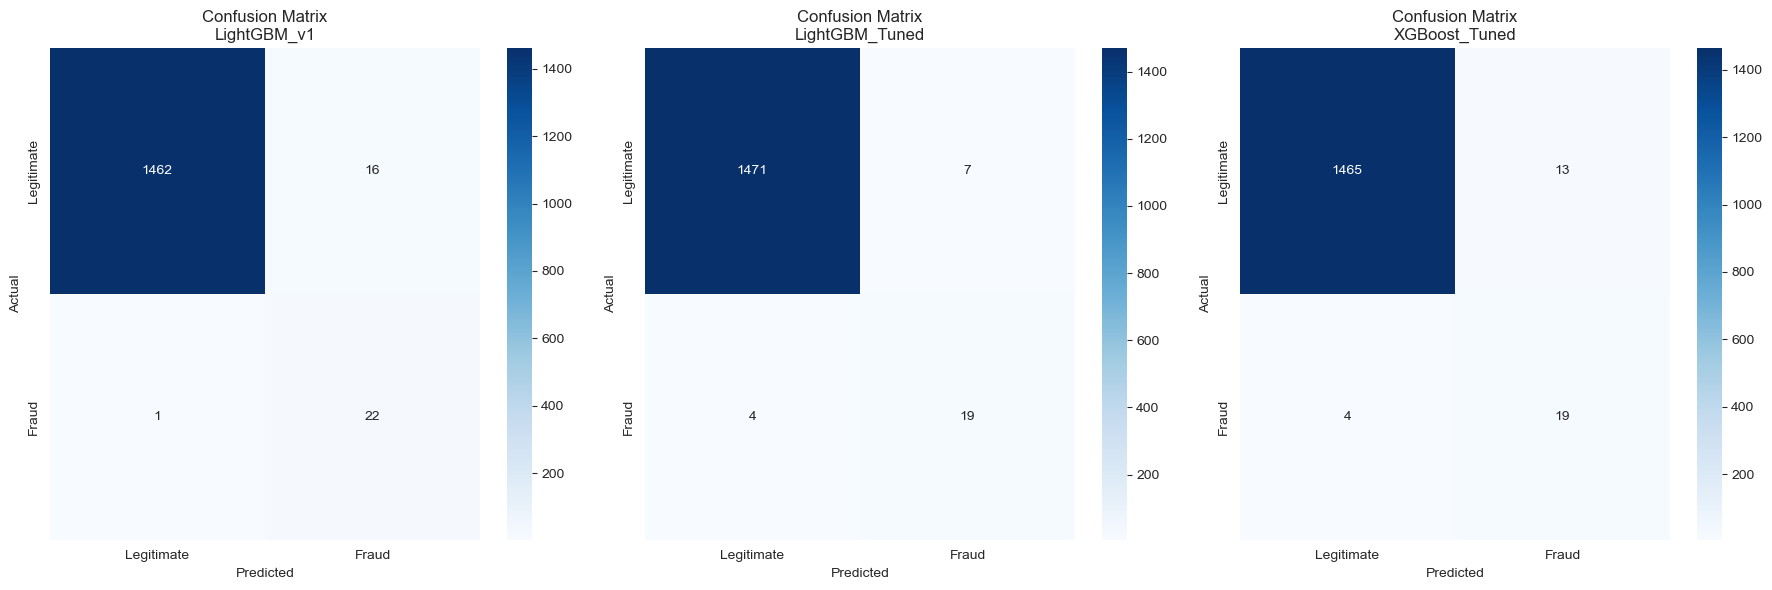

Confusion matrices saved as 'confusion_matrices.png'


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, result in enumerate(final_evaluation_results):
    cm = result['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx])
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
    axes[idx].set_title(f"Confusion Matrix\n{result['model_name']}")
    axes[idx].set_xticklabels(['Legitimate', 'Fraud'])
    axes[idx].set_yticklabels(['Legitimate', 'Fraud'])

plt.tight_layout()
plt.savefig('../outputs/model_selection/images/confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrices saved as 'confusion_matrices.png'")

In [10]:
best_model_result = final_results_df.loc[final_results_df['f1_score'].idxmax()]
best_model_name = best_model_result['model_name']
best_model_info = final_models[best_model_name]

print(f"ERROR ANALYSIS - BEST MODEL: {best_model_name}")

y_pred_best = best_model_info['model'].predict(X_test)
y_proba_best = best_model_info['model'].predict_proba(X_test)[:, 1]

false_negatives_idx = np.where((Y_test['is_fraud'].values == 1) & (y_pred_best == 0))[0]
false_positives_idx = np.where((Y_test['is_fraud'].values == 0) & (y_pred_best == 1))[0]

print(f"\nTotal False Negatives: {len(false_negatives_idx)}")
print(f"Total False Positives: {len(false_positives_idx)}")

if len(false_negatives_idx) > 0:
    print("\nFalse Negatives Analysis (Missed Fraud)")
    fn_data = X_test.iloc[false_negatives_idx]
    print(f"Average transaction amount (log): {fn_data['log_amount'].mean():.4f}")
    print(f"Average velocity per hour: {fn_data['velocity_per_hour'].mean():.4f}")
    print(f"Average device trust score: {fn_data['device_trust_score'].mean():.4f}")
    print(f"High risk abroad rate: {fn_data['high_risk_abroad'].mean()*100:.2f}%")
    print(f"Night transaction rate: {fn_data['is_night_transaction'].mean()*100:.2f}%")

if len(false_positives_idx) > 0:
    print("\nFalse Positives Analysis (False Alarms)")
    fp_data = X_test.iloc[false_positives_idx]
    print(f"Average transaction amount (log): {fp_data['log_amount'].mean():.4f}")
    print(f"Average velocity per hour: {fp_data['velocity_per_hour'].mean():.4f}")
    print(f"Average device trust score: {fp_data['device_trust_score'].mean():.4f}")
    print(f"High risk abroad rate: {fp_data['high_risk_abroad'].mean()*100:.2f}%")
    print(f"Night transaction rate: {fp_data['is_night_transaction'].mean()*100:.2f}%")

ERROR ANALYSIS - BEST MODEL: LightGBM_Tuned

Total False Negatives: 4
Total False Positives: 7

False Negatives Analysis (Missed Fraud)
Average transaction amount (log): 0.1594
Average velocity per hour: 0.0079
Average device trust score: -1.2859
High risk abroad rate: 0.00%
Night transaction rate: 75.00%

False Positives Analysis (False Alarms)
Average transaction amount (log): 0.7575
Average velocity per hour: 2.7539
Average device trust score: -0.8797
High risk abroad rate: 0.00%
Night transaction rate: 71.43%


In [11]:
print("FINAL MODEL SELECTION RECOMMENDATION")

final_results_df['composite_score'] = (
    0.35 * final_results_df['f1_score'] + 
    0.30 * final_results_df['roc_auc'] + 
    0.20 * (final_results_df['recall']) + 
    0.10 * (1 - final_results_df['false_alarm_rate']/100) +
    0.05 * (final_results_df['potential_savings'] / final_results_df['potential_savings'].max())
)

final_results_df = final_results_df.sort_values('composite_score', ascending=False)

recommended_model = final_results_df.iloc[0]

print(f"\nRECOMMENDED MODEL: {recommended_model['model_name']}")
print(f"\nPerformance Metrics:")
print(f"F1-Score: {recommended_model['f1_score']:.4f}")
print(f"ROC-AUC: {recommended_model['roc_auc']:.4f}")
print(f"Precision: {recommended_model['precision']:.4f}")
print(f"Recall (Fraud Detection Rate): {recommended_model['recall']:.4f} ({recommended_model['fraud_detection_rate']:.2f}%)")
print(f"Accuracy: {recommended_model['accuracy']:.4f}")

print(f"\nBusiness Impact:")
print(f"Total Business Cost: ${recommended_model['total_business_cost']:,}")
print(f"Potential Savings: ${recommended_model['potential_savings']:,}")
print(f"ROI: {recommended_model['roi_percentage']:.2f}%")
print(f"False Alarm Rate: {recommended_model['false_alarm_rate']:.2f}%")

print(f"\nMLflow Run ID: {recommended_model['run_id']}")

recommendation = {
    'recommended_model': recommended_model['model_name'],
    'run_id': recommended_model['run_id'],
    'f1_score': recommended_model['f1_score'],
    'roc_auc': recommended_model['roc_auc'],
    'recall': recommended_model['recall'],
    'precision': recommended_model['precision'],
    'fraud_detection_rate': recommended_model['fraud_detection_rate'],
    'total_business_cost': recommended_model['total_business_cost'],
    'potential_savings': recommended_model['potential_savings'],
    'roi_percentage': recommended_model['roi_percentage']
}

pd.DataFrame([recommendation]).to_csv('../outputs/model_selection/csv/final_model_recommendation.csv', index=False)
print("\nRecommendation saved as 'final_model_recommendation.csv'")

FINAL MODEL SELECTION RECOMMENDATION

RECOMMENDED MODEL: LightGBM_v1

Performance Metrics:
F1-Score: 0.7213
ROC-AUC: 0.9970
Precision: 0.5789
Recall (Fraud Detection Rate): 0.9565 (95.65%)
Accuracy: 0.9887

Business Impact:
Total Business Cost: $310
Potential Savings: $4,240
ROI: 1367.74%
False Alarm Rate: 1.08%

MLflow Run ID: 91740bf8a7be4e99baa37dfc79ec9fbe

Recommendation saved as 'final_model_recommendation.csv'


**Model Selected**
The model selected for this project is the LightGBM model. It has the high F1-score. The model also has the highest ROI percentage. The model has the highest recall score. High ROC. High Fraude detection rate.

In [12]:
print("EXPORTING FINAL MODEL FOR DEPLOYMENT")

final_model = final_models[recommended_model['model_name']]['model']

joblib.dump(final_model, '../models/final_fraud_detection_model.pkl')
print("Model saved as 'final_fraud_detection_model.pkl'")

preprocessing_info = {
    'model_name': recommended_model['model_name'],
    'run_id': recommended_model['run_id'],
    'expected_features': list(X_test.columns),
    'feature_count': len(X_test.columns),
    'scaling': 'StandardScaler (already applied)',
    'date_trained': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'performance': {
        'f1_score': float(recommended_model['f1_score']),
        'roc_auc': float(recommended_model['roc_auc']),
        'recall': float(recommended_model['recall'])
    }
}

with open('../outputs/model_selection/json/model_deployment_info.json', 'w') as f:
    json.dump(preprocessing_info, f, indent=2)

print("Model deployment info saved as 'model_deployment_info.json'")

EXPORTING FINAL MODEL FOR DEPLOYMENT
Model saved as 'final_fraud_detection_model.pkl'
Model deployment info saved as 'model_deployment_info.json'


### Summary
- Loaded top 3 models from MLflow  
- Evaluated all models on test set  
- Calculated final business metrics  
- Performed error analysis  
- Generated comprehensive visualizations  
- Selected final recommended model  
- Exported model for deployment  

## Business Interpretation

### What the Results Mean for Stakeholders
- With a 95.65% fraud detection rate, the model prevents ~$4,240 in fraud losses per validation batch
- The 1.08% false alarm rate means minimal customer friction from unnecessary transaction blocks
- ROI of 1,367% indicates strong business value: every $1 spent on investigation yields ~$13.67 in prevented losses

### Trade-offs & Decision Support
- High recall prioritized over precision: acceptable in fraud detection where missed fraud is costlier ($150) than false alarms ($10)
- Model enables automated flagging of high-risk transactions while routing borderline cases to human review

### Limitations
- Model performance may degrade with concept drift (new fraud patterns)
- Features like `device_trust_score` require real-time data infrastructure
- SMOTE augmentation may introduce synthetic patterns not present in production data

### Future Work
- Implement model monitoring for performance drift
- Add ensemble methods or neural networks for marginal gains
- Integrate real-time feature engineering pipeline